# Sector Rotation Analysis: US Equity ETFs (2020-2024)

**Track 2 – GitHub Data Analysis Project**

- Problem: Do sector returns rotate across macro regimes, and which sectors lead under different market conditions?
- Target users: retail investors and finance/economics students
- Universe: Technology, Consumer Discretionary, Energy, Health Care, Financials
- Proxy ETFs: `XLK`, `XLY`, `XLE`, `XLV`, `XLF`
- Data source: Yahoo Finance via `yfinance`
- Analysis window: 2020-01-01 to 2024-12-31
- Access date: 2026-04-21


## 1. Setup

This notebook follows the required structure from the project plan:

1. Download sector ETF data
2. Clean prices and compute daily/monthly returns
3. Compare cumulative returns, annual and quarterly heatmaps, correlation, and rolling volatility
4. Rank yearly winners and laggards
5. Summarize actionable findings


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src.sector_rotation_analysis import (
    ACCESS_DATE,
    END_DATE,
    START_DATE,
    TICKER_MAP,
    build_analysis,
    configure_plot_style,
    plot_annual_heatmap,
    plot_correlation_heatmap,
    plot_cumulative_returns,
    plot_quarterly_heatmap,
    plot_rolling_volatility,
    plot_yearly_winners,
)

root = Path.cwd()
bundle = build_analysis(root)
configure_plot_style()
bundle.prices.head()


,Technology,Consumer Discretionary,Energy,Health Care,Financials
Date,,,,,
2020-01-02,44.294182,60.155190,23.356087,92.306099,27.642971
2020-01-03,43.796177,59.643272,23.286694,91.501686,27.349463
2020-01-06,43.900528,59.809166,23.467894,92.071114,27.331676
2020-01-07,43.881554,59.714363,23.406206,91.890320,27.153797
2020-01-08,44.351105,59.894482,23.020662,92.486855,27.331676


## 2. Data Overview

The adjusted close series are forward-filled after download and then aligned on common trading days.
The transformed outputs are also saved to `data/` so the GitHub repository includes reproducible artifacts.


In [2]:
display(bundle.prices.tail())
display(bundle.daily_returns.describe().T[["mean", "std", "min", "max"]].sort_values("mean", ascending=False))


,Technology,Consumer Discretionary,Energy,Health Care,Financials
Date,,,,,
2024-12-24,119.372025,115.996376,40.686275,136.351318,48.070400
2024-12-26,119.451424,115.565979,40.652622,136.625366,48.188148
2024-12-27,117.863312,113.656357,40.647812,135.989197,47.834904
2024-12-30,116.364525,111.830864,40.643013,134.315643,47.373730
2024-12-31,115.396767,110.989838,41.176590,134.638611,47.422791


,mean,std,min,max
Technology,0.000917,0.017610,-0.138140,0.117320
Energy,0.000717,0.022934,-0.201412,0.160373
Consumer Discretionary,0.000623,0.016414,-0.126686,0.093797
Financials,0.000568,0.016605,-0.137093,0.131566
Health Care,0.000367,0.011553,-0.098610,0.077057


## 3. Cumulative Return Comparison

This chart answers the most direct question: which sector created the most value over the full five-year period?


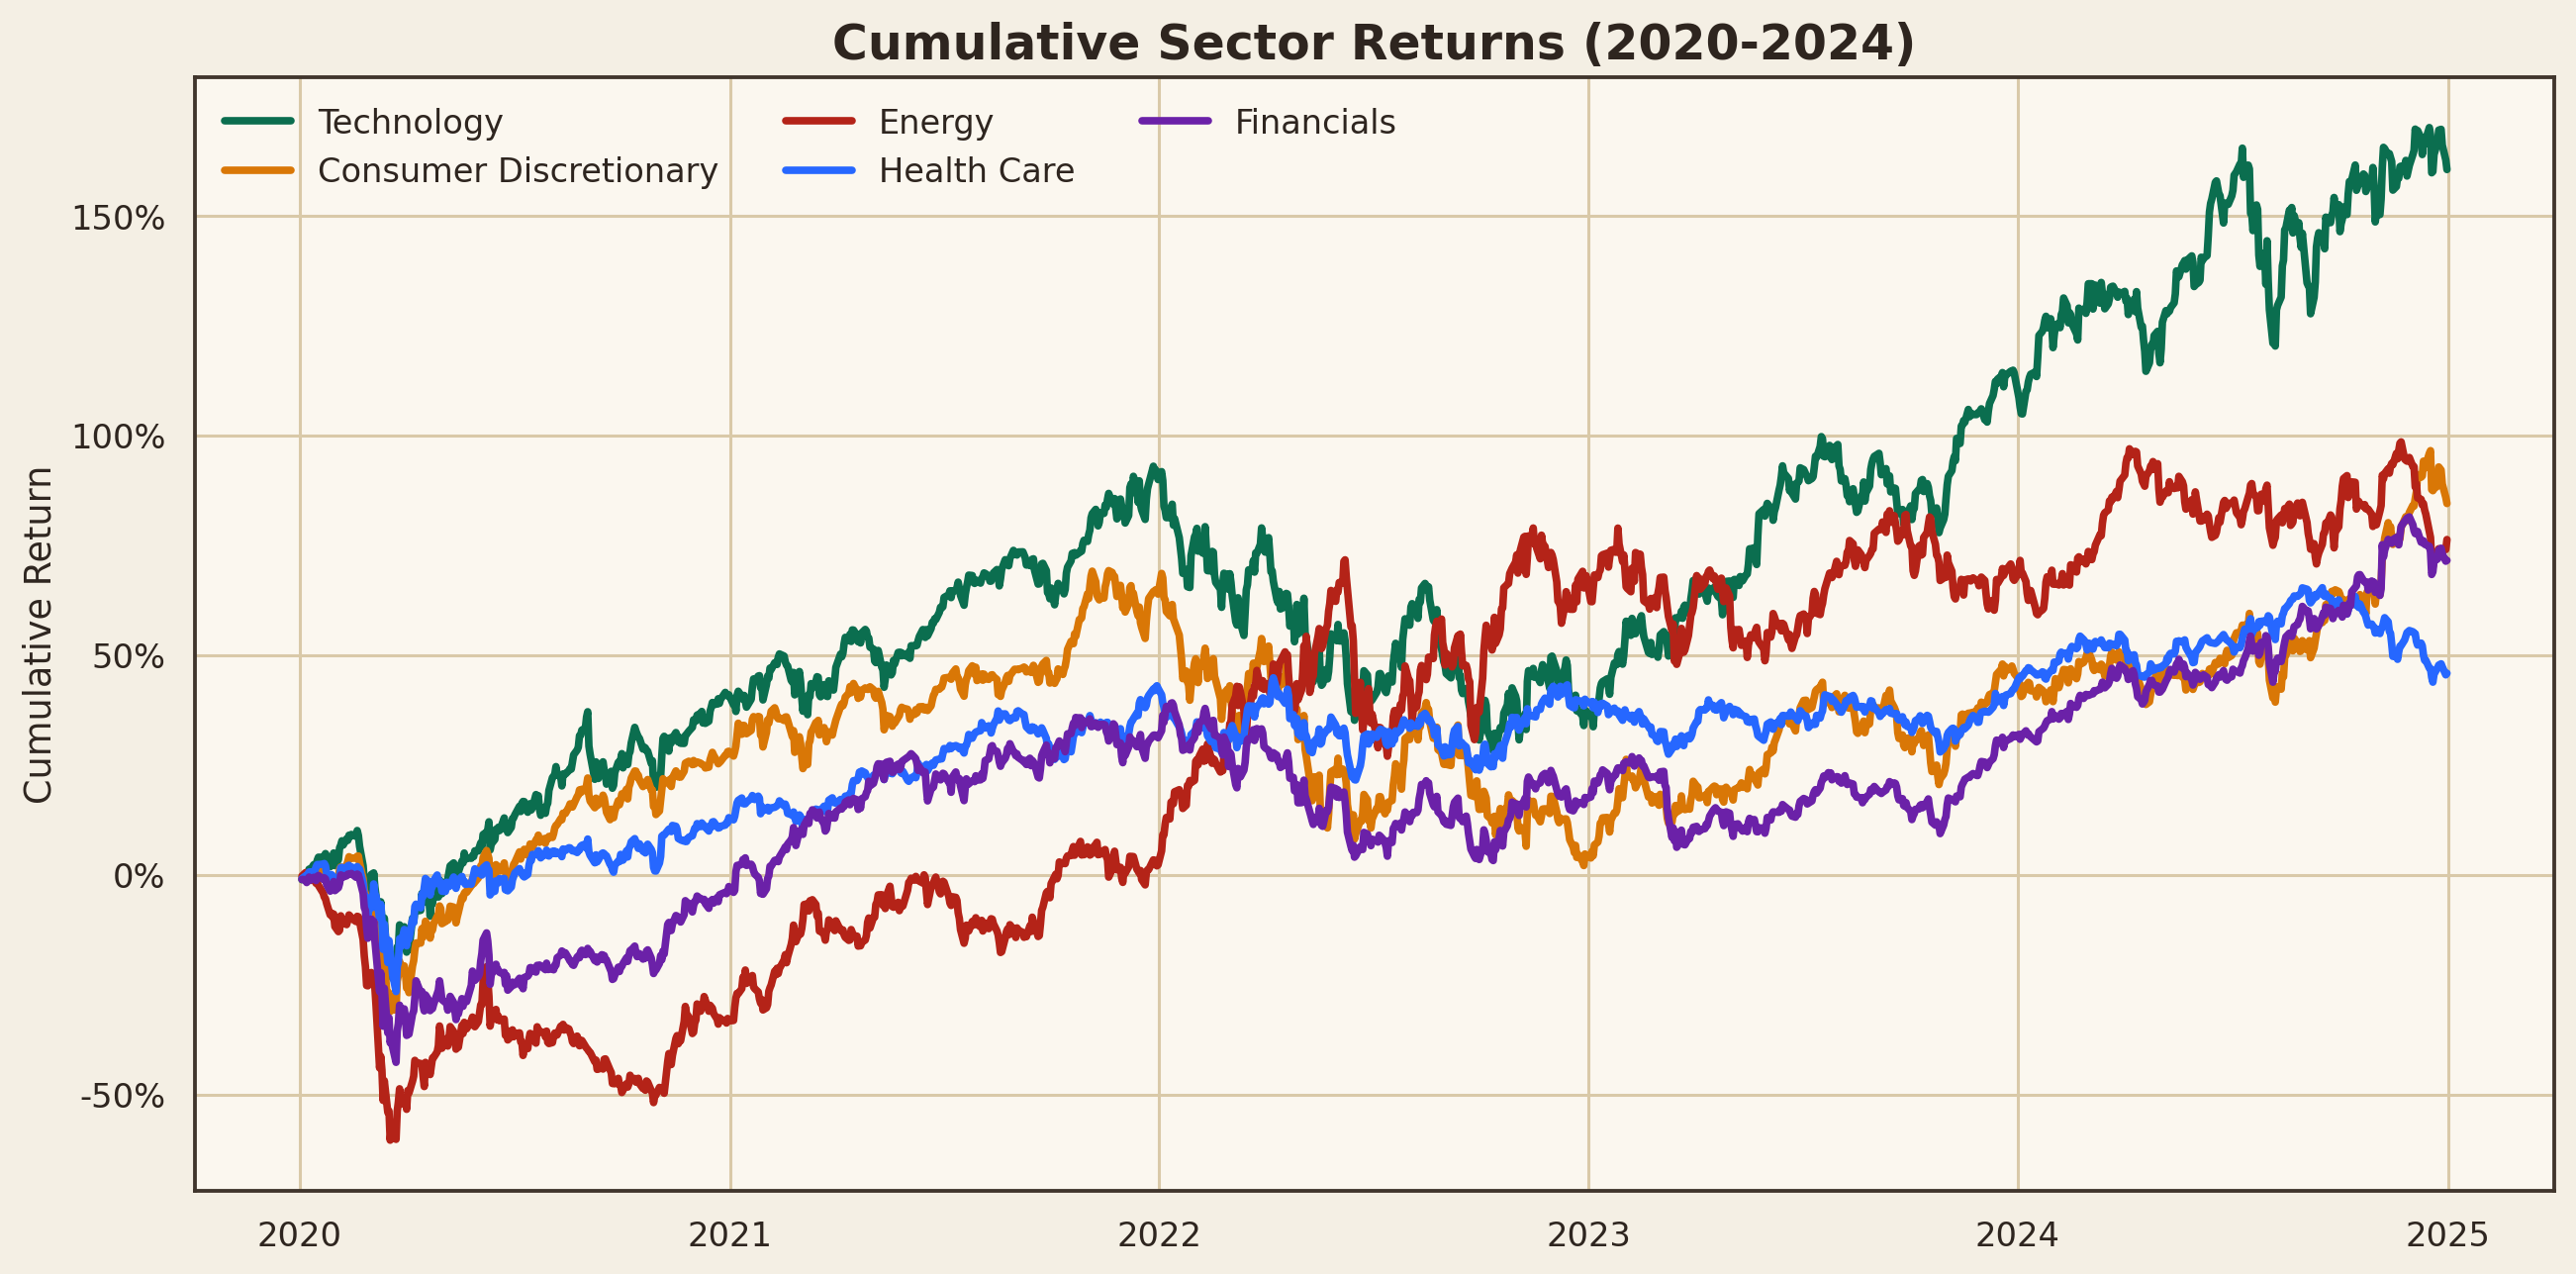

,CAGR,Total Return,Annualized Volatility,Best Month,Worst Month
Technology,21.1%,160.5%,28.0%,13.7%,-12.0%
Consumer Discretionary,13.0%,84.5%,26.1%,18.9%,-14.9%
Energy,12.0%,76.3%,36.4%,30.8%,-34.4%
Financials,11.4%,71.6%,26.4%,16.8%,-21.0%
Health Care,7.8%,45.9%,18.3%,12.6%,-6.9%


In [3]:
plot_cumulative_returns(bundle, root / "figures" / "cumulative_returns.png")
display(Image(filename=str(root / "figures" / "cumulative_returns.png")))
display(bundle.summary_metrics.style.format("{:.1%}"))


## 4. Annual and Quarterly Rotation Heatmaps

The annual heatmap highlights regime shifts from year to year, while the quarterly heatmap shows shorter rotation cycles.


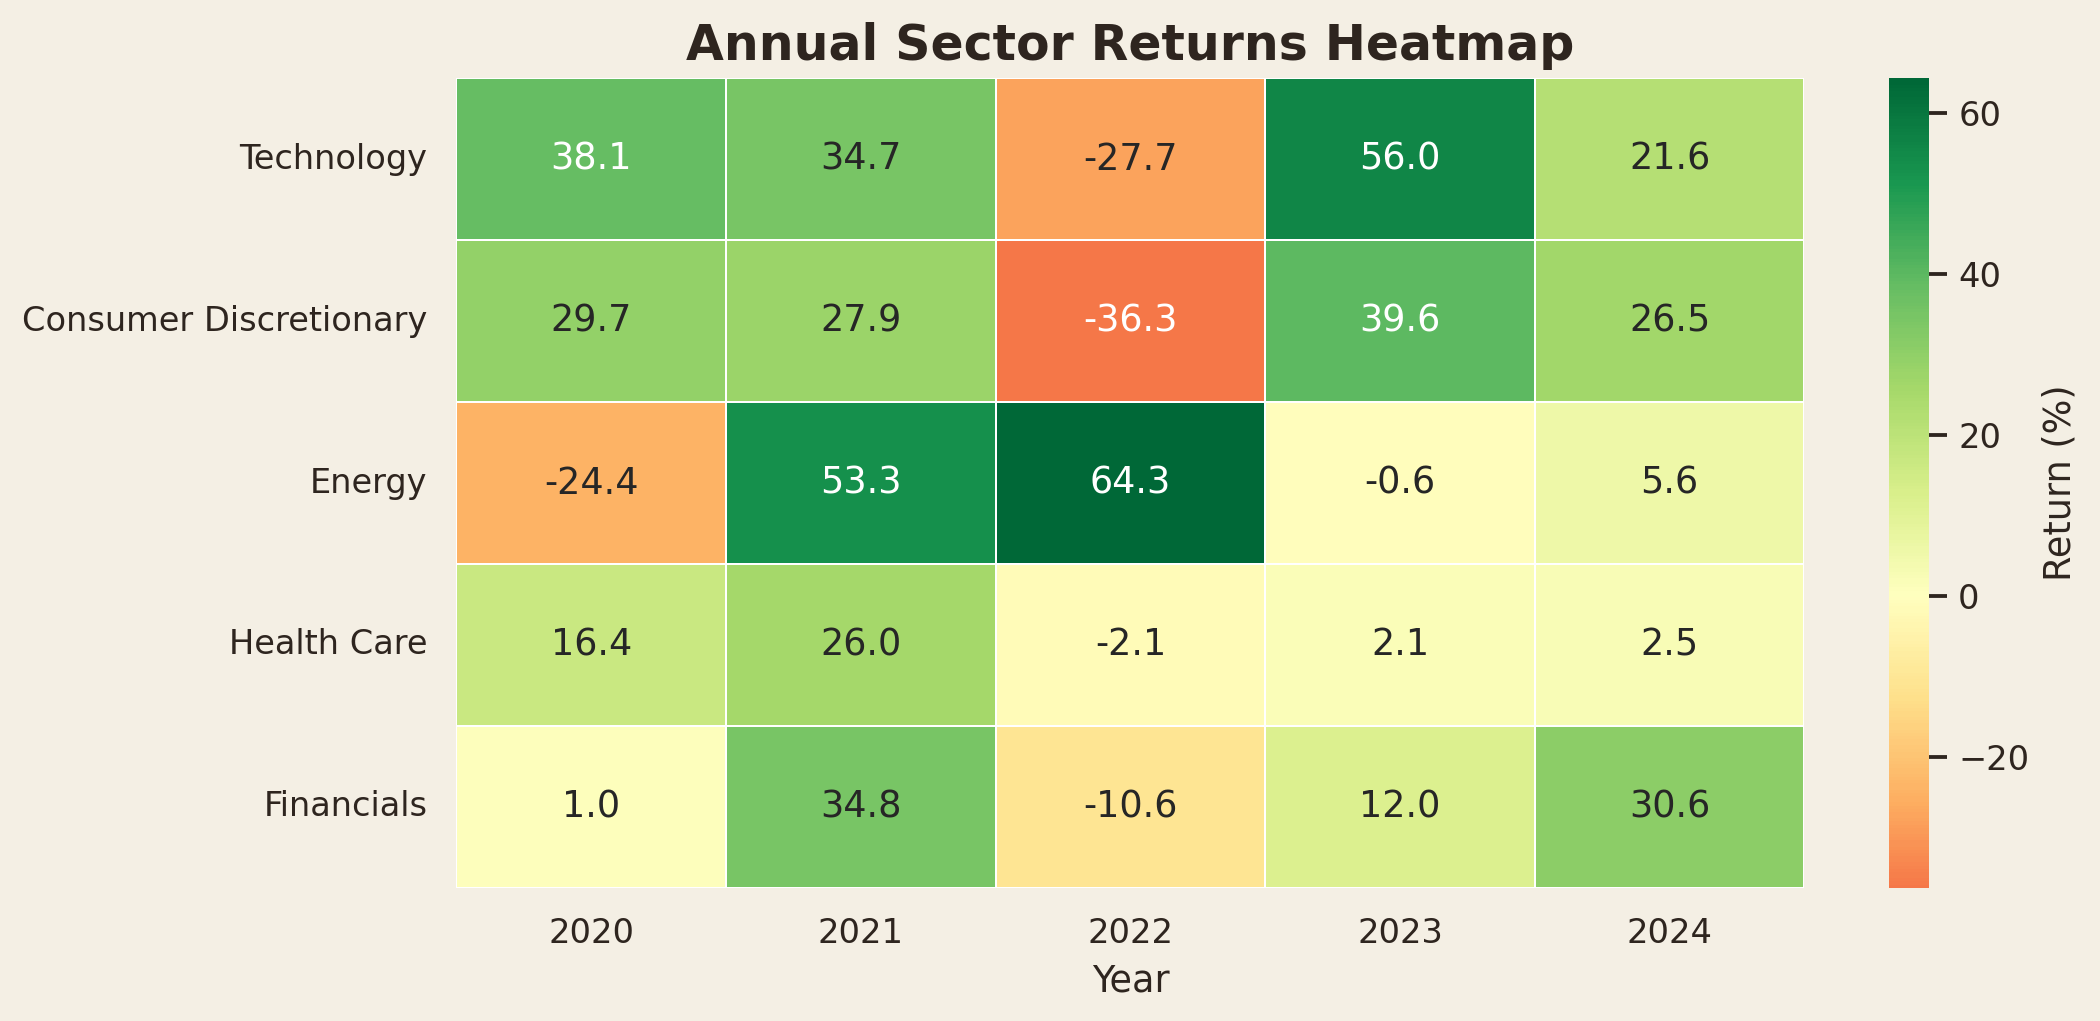

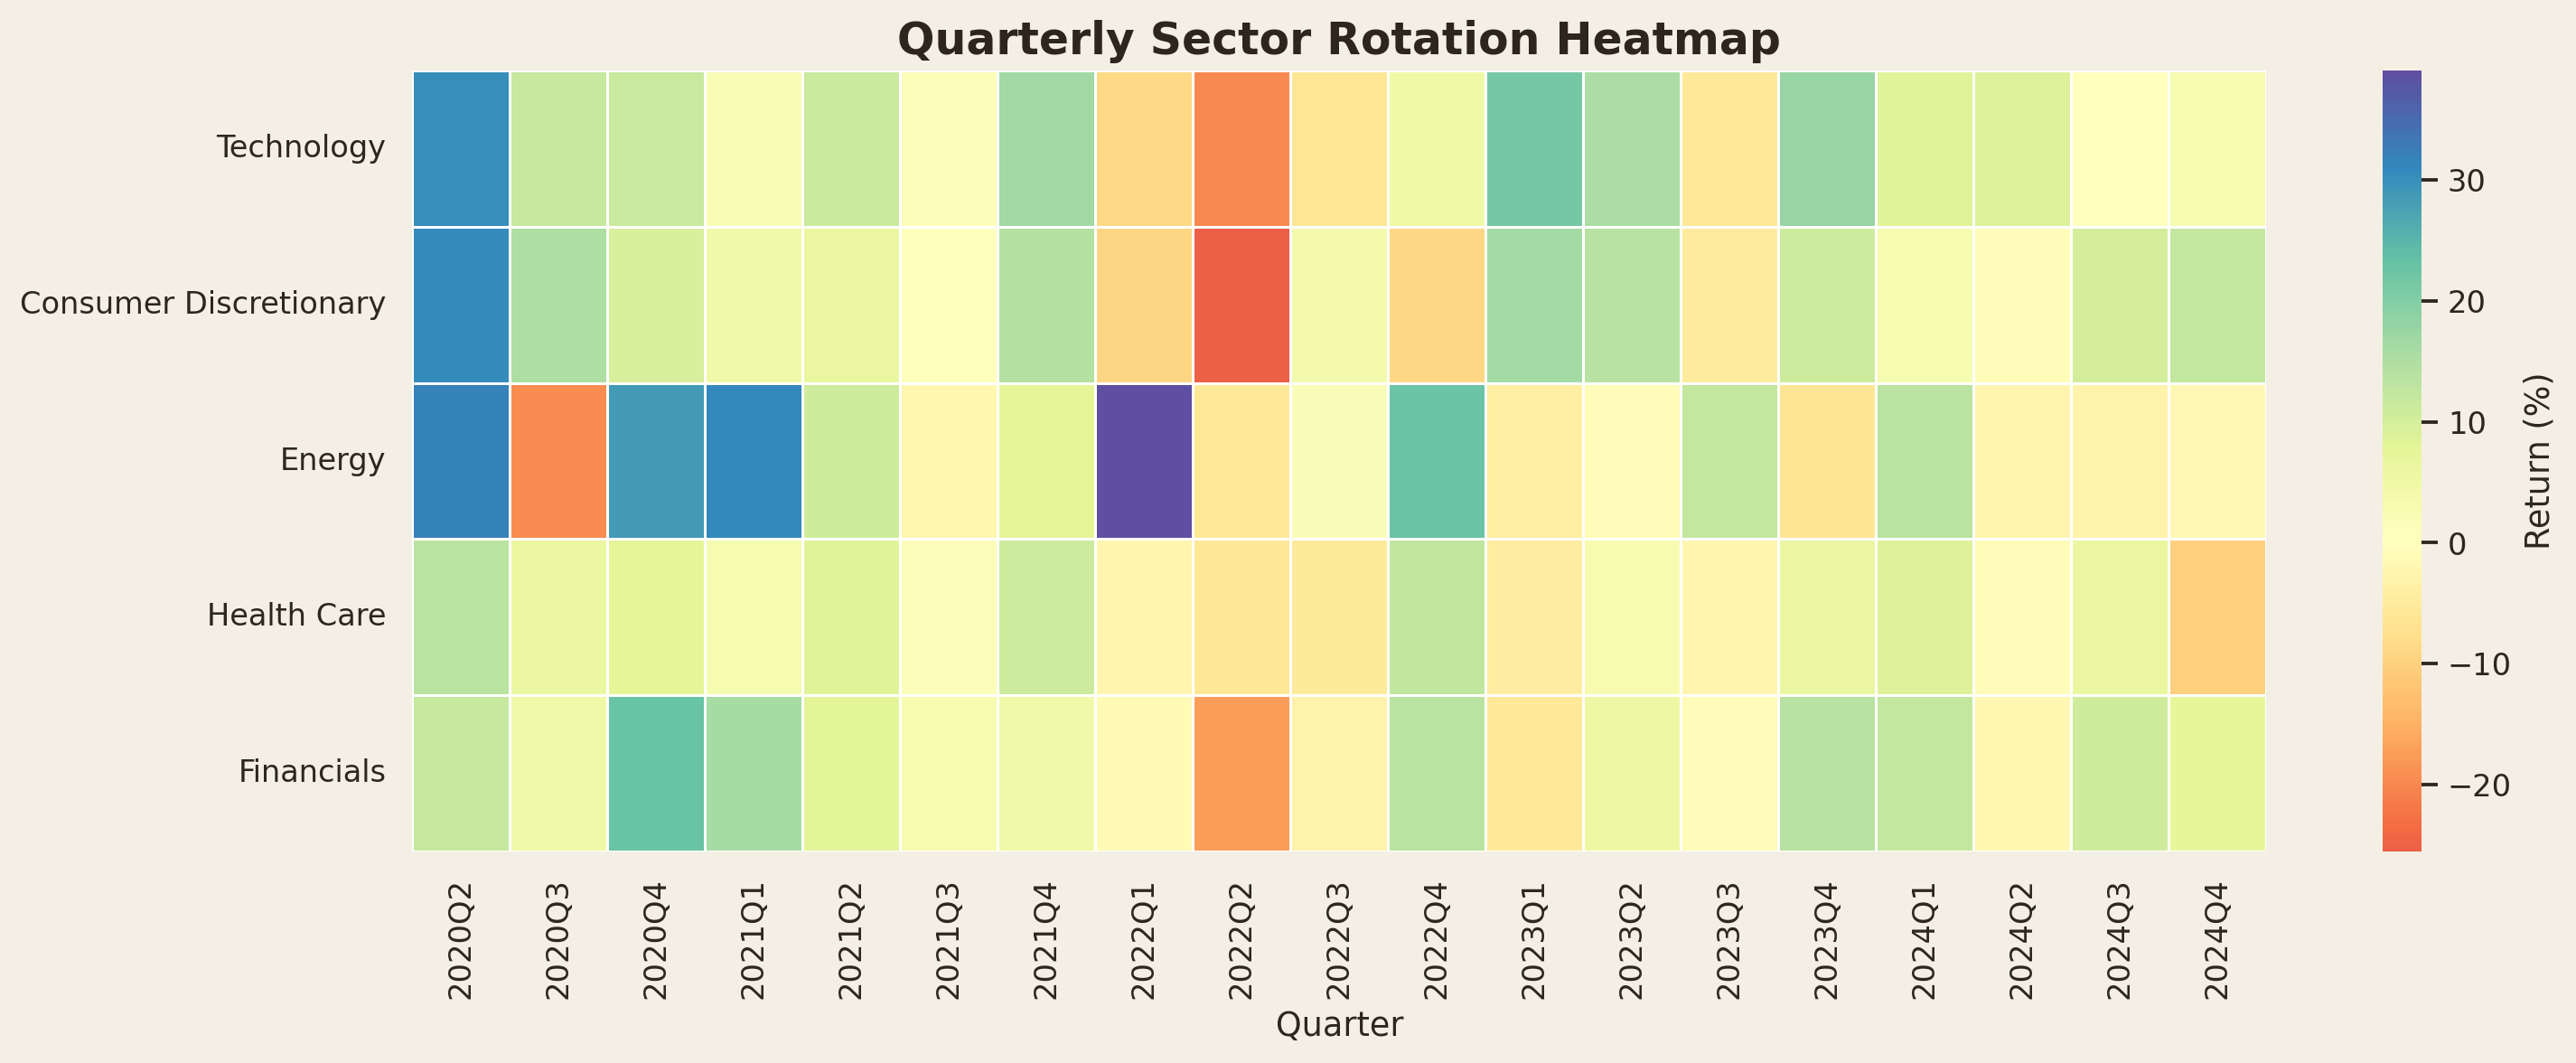

,Technology,Consumer Discretionary,Energy,Health Care,Financials
Year,,,,,
2020,38.1%,29.7%,-24.4%,16.4%,1.0%
2021,34.7%,27.9%,53.3%,26.0%,34.8%
2022,-27.7%,-36.3%,64.3%,-2.1%,-10.6%
2023,56.0%,39.6%,-0.6%,2.1%,12.0%
2024,21.6%,26.5%,5.6%,2.5%,30.6%


In [4]:
plot_annual_heatmap(bundle, root / "figures" / "annual_returns_heatmap.png")
plot_quarterly_heatmap(bundle, root / "figures" / "quarterly_returns_heatmap.png")
display(Image(filename=str(root / "figures" / "annual_returns_heatmap.png")))
display(Image(filename=str(root / "figures" / "quarterly_returns_heatmap.png")))
display(bundle.annual_returns.style.format("{:.1%}"))


## 5. Correlation and Risk

Correlation shows which sectors move together. Rolling volatility adds a risk lens and shows where uncertainty spiked.


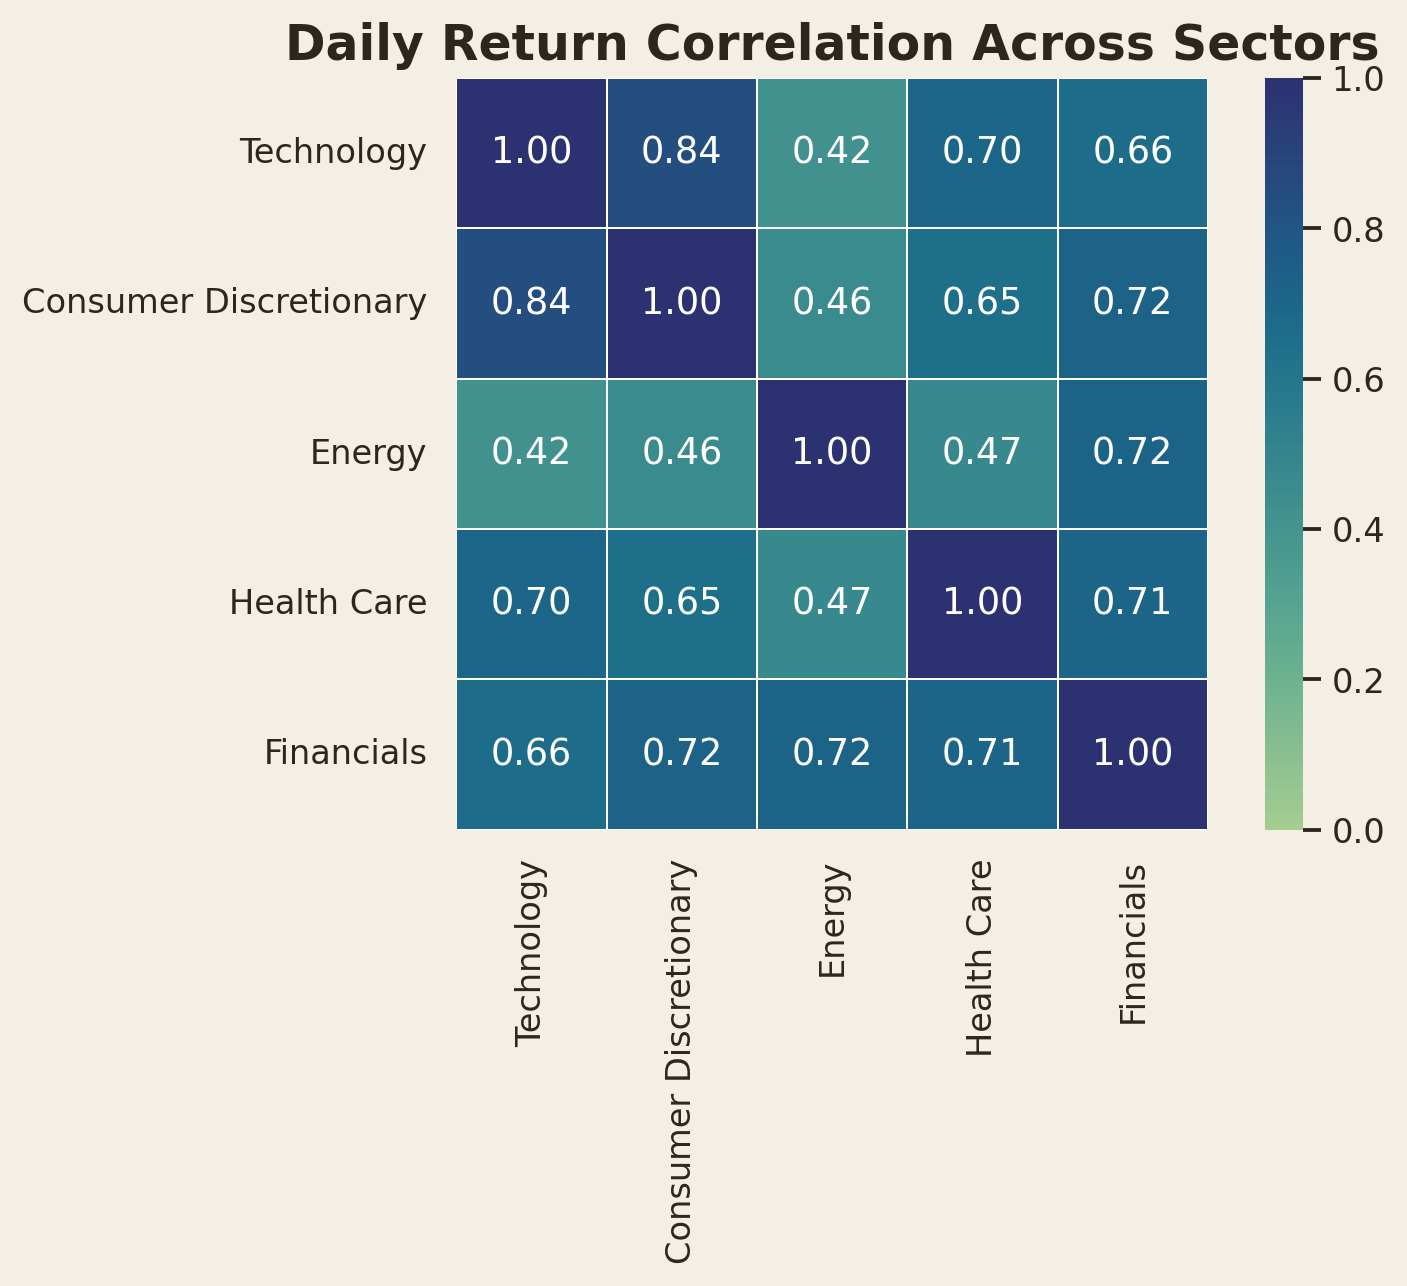

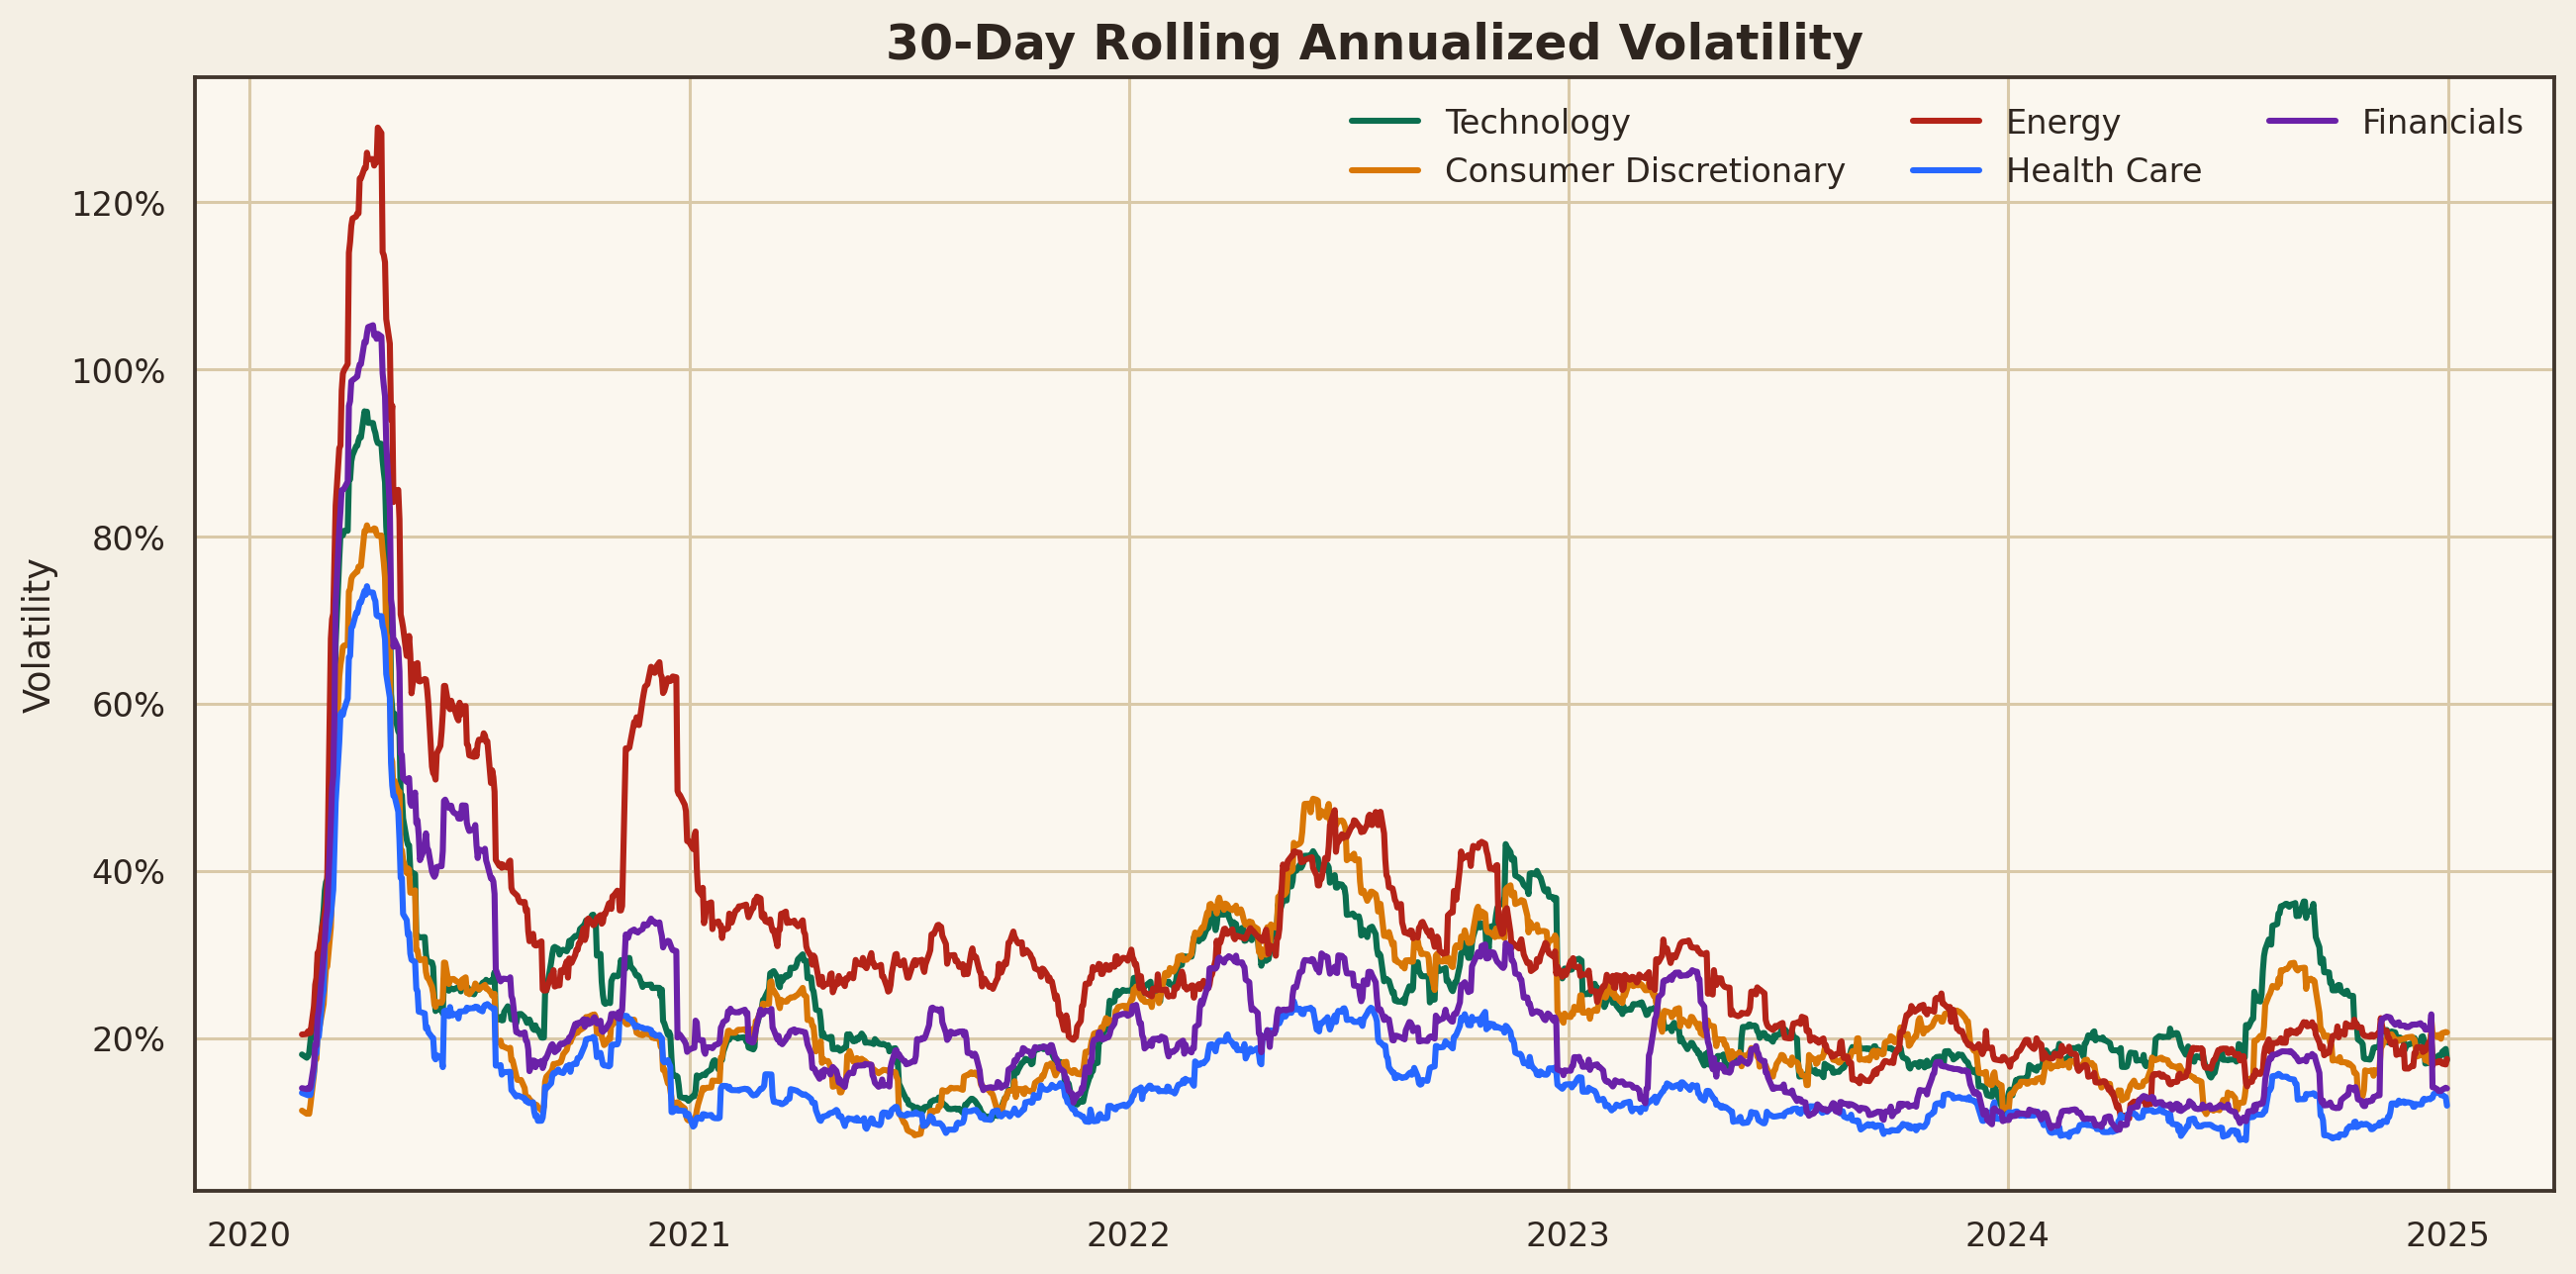

,Technology,Consumer Discretionary,Energy,Health Care,Financials
Technology,1.00,0.84,0.42,0.70,0.66
Consumer Discretionary,0.84,1.00,0.46,0.65,0.72
Energy,0.42,0.46,1.00,0.47,0.72
Health Care,0.70,0.65,0.47,1.00,0.71
Financials,0.66,0.72,0.72,0.71,1.00


In [5]:
plot_correlation_heatmap(bundle, root / "figures" / "correlation_heatmap.png")
plot_rolling_volatility(bundle, root / "figures" / "rolling_volatility.png")
display(Image(filename=str(root / "figures" / "correlation_heatmap.png")))
display(Image(filename=str(root / "figures" / "rolling_volatility.png")))
display(bundle.correlation_matrix.style.format("{:.2f}"))


## 6. Yearly Winners and Laggards

This ranking view is useful for summarizing sector leadership in a way that non-technical audiences can read quickly.


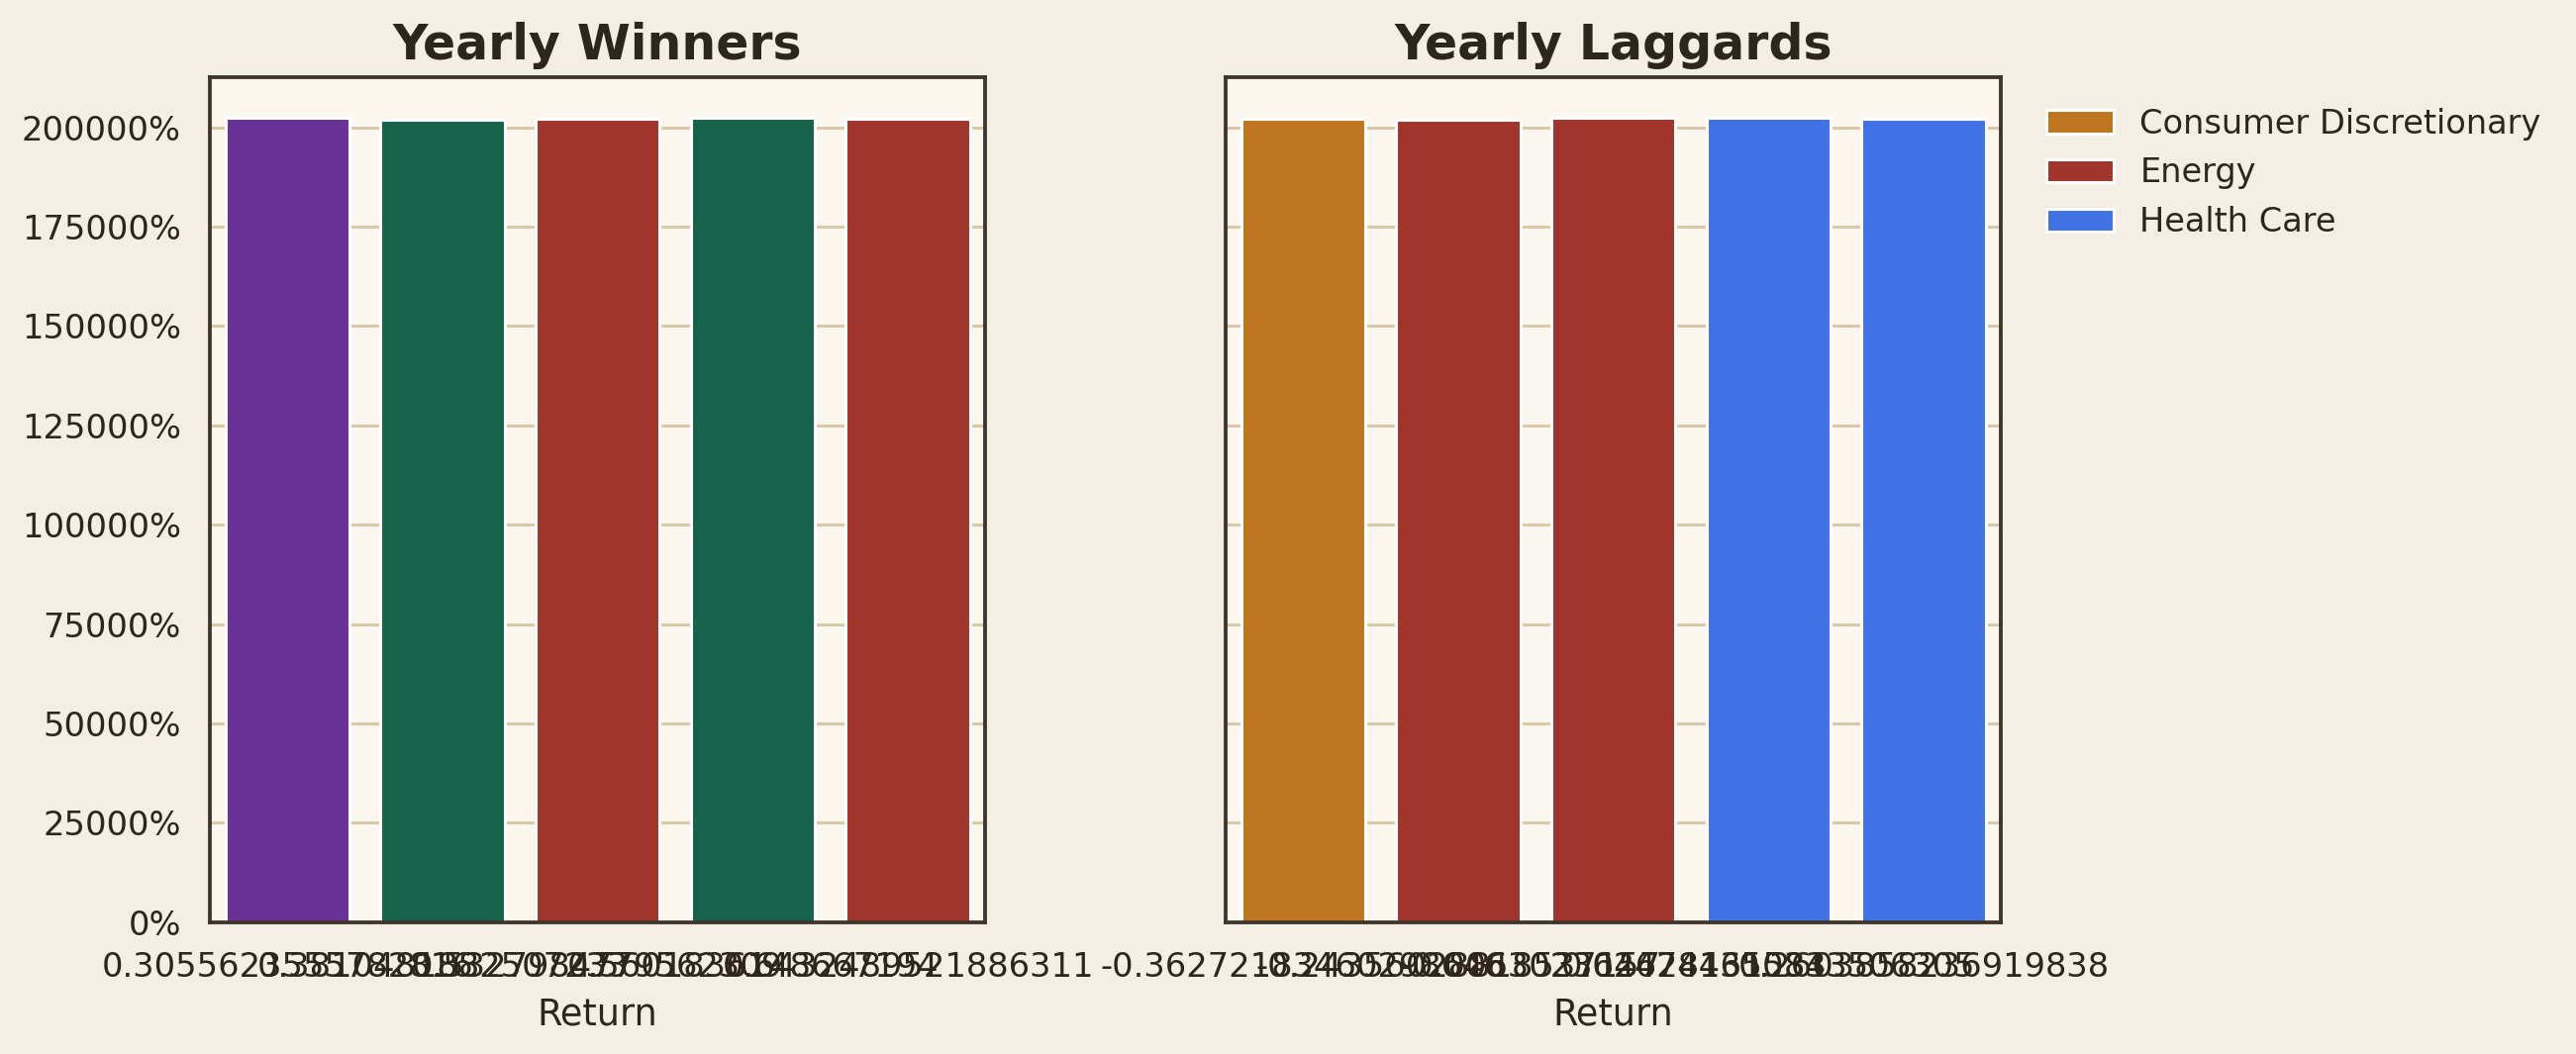

,Year,Sector,return,rank
0,2020,Technology,0.381048,1.0
1,2020,Consumer Discretionary,0.297338,2.0
3,2020,Health Care,0.164036,3.0
4,2020,Financials,0.009531,4.0
2,2020,Energy,-0.243560,5.0
7,2021,Energy,0.532798,1.0
9,2021,Financials,0.347978,2.0
5,2021,Technology,0.347441,3.0
6,2021,Consumer Discretionary,0.279281,4.0
8,2021,Health Care,0.260386,5.0


In [6]:
plot_yearly_winners(bundle, root / "figures" / "yearly_winners_laggards.png")
display(Image(filename=str(root / "figures" / "yearly_winners_laggards.png")))
display(bundle.yearly_rankings.sort_values(["Year", "rank"]).head(15))


## 7. Key Findings

The statements below are generated from the analysis outputs rather than written by hand.


In [7]:
for idx, finding in enumerate(bundle.findings, start=1):
    print(f"{idx}. {finding}")


1. In 2022, Energy was the only clear defensive winner, returning 64.3%, while Consumer Discretionary dropped 36.3%.
2. The 2023 rebound was led by Technology, which gained 56.0% as growth assets recovered.
3. Across the full 2020-2024 window, Technology delivered the highest total return at 160.5%, while Health Care lagged at 45.9%.
4. The tightest daily co-movement came from Technology and Consumer Discretionary, with a correlation of 0.84, indicating strong cyclical overlap.
5. Sector leadership changed materially between the pandemic shock, the 2022 hiking cycle, and the 2023-2024 recovery, which supports a rotation-based allocation lens.


## 8. Conclusion

The evidence supports a rotation narrative:

- leadership changed significantly across the pandemic, the 2022 hiking cycle, and the later recovery;
- sector choice materially affected both return and risk outcomes;
- a diversified or rotation-aware allocation framework is more defensible than treating all sectors as interchangeable.
